## Logisztikus regresszió

Bináris klasszifikáció:
- input: $\underline{x}$ = [$x_1$, ..., $x_p$] ($p$ darab feature (real), ahogy eddig)
- output (predikció): 0 vagy 1 (kategórikus)
- ... vagy egy valószínűségi érték

Modell paraméterek:
- $\underline{w}$ ($p$ darab paraméter)
- $b$ bias (+1 paraméter, $w_0$)
  
Ouput (logisztikus regresszió):
- output: $\hat y = σ(\underline{w} \cdot \underline{x} + b)$, ahol
- $σ$ a __sigmoid__ függvény: $σ(z) = \frac{1}{1+e^{−z}}$
- 0-1 közötti valózínűségi érték,  $\hat y = P(y = 1|\underline{x_i})$: mekkora az esélye annak, hogy y = 1, adott $\underline{x_i}$ esetén
- => 0.5 felett 1-et érdemes "tippelni": __1__ if $\hat y$  > 0.5 else __0__
- 0.5 küszöbérték


Veszteségfüggvény (loss function):
- prediktált valószínűség $\hat y_i$ és elvárt output $y_i$ (0 vagy 1, ground truth) $\underline{x_i}$ input-ra
- a hiba metrika: Binary Cross-Entropy (BCE, _log loss_), amelyet minimalizálni szeretnénk ($log=log_e$):

\begin{equation}
L_{BCE} (\underline{y},  \underline{\hat y}) = -\frac{1}{n} \sum_{i=1}^{n} ( y_i \log(\hat y_i) + (1-y_i) *  \log(1- \hat y_i))
\end{equation}
- vagy:

\begin{equation}
L_{BCE} (\underline{y},  \underline{\hat y}) = \frac{1}{n} ( \sum_{\forall y_i = 1} -\log(\hat y_i) +  \sum_{\forall y_i = 0} -\log(1- \hat y_i) )
\end{equation}


Feltételezi, hogy:
- függetlenek a bemenetek (ahogy lin. regressziónál)
- nincsenek nagyon kilógó pontok (outlier-ek)
- ...

<div>
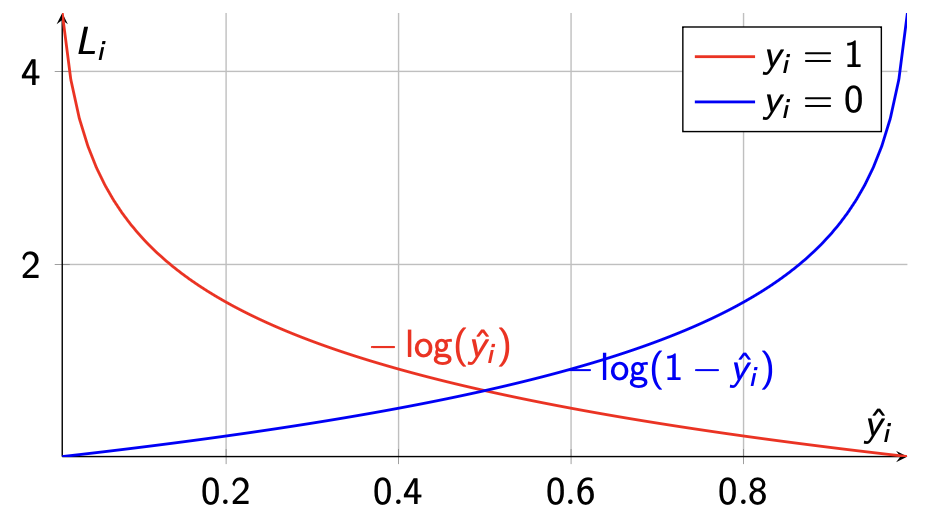
</div>

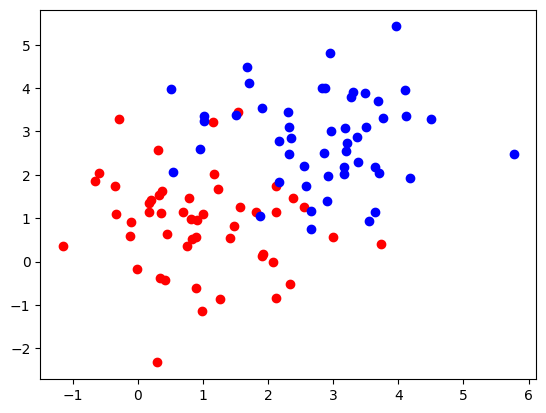

In [7]:
# !pip install scikit-learn
import numpy as np
import matplotlib.pyplot as plt

X = np.zeros((100, 2))
X[0:50] = X[0:50] + np.array([1, 1]) # egyik class (1,1) középponttal
X[50:100] = X[50:100] + np.array([3, 3]) # másik class (3,3) középponttal
X = X + np.random.randn(100, 2) # zaj

y = np.array([0] * 50 + [1] * 50) # lista 50 db. 0-asbol, majd 50 db. 1-esbol

plt.scatter(X[0:50,0], X[0:50,1], color="red")
plt.scatter(X[50:100,0], X[50:100,1], color="blue")

In [8]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X, y)
w = log_reg.coef_ # array (1, p)
b = log_reg.intercept_ # array (1,)
print("w:", w, "b:", b)

y_ = log_reg.predict(X) # [0,..., 0, 1, ..., 1]
y_prob = log_reg.predict_proba(X)[:,1] # mekkora az esélye, hogy 1-es class-ú
print(y_prob[:5]) # [0.00025163, 0.00092073, 0.00297153, 0.00080611, 0.02283239]
print(y_prob[95:]) # [0.99985413, 0.97572643, 0.94733491, 0.91073099, 0.99907433]

from sklearn.metrics import log_loss
print("BCE:", log_loss(y, y_prob))
# y[49:51]      # [0,          1]
# y_prob[49:51] # [0.0361753 , 0.99642084] 
# = > -1/2 * (np.log(1-0.0361753) + np.log(0.99642084))

w: [[1.57354014 1.61978178]] b: [-5.96809481]
[0.02863752 0.01472654 0.02163509 0.04339328 0.06601843]
[0.99337354 0.99306116 0.99988137 0.93780236 0.43192813]
BCE: 0.2062069501888163


## Döntési határ (hipersík)

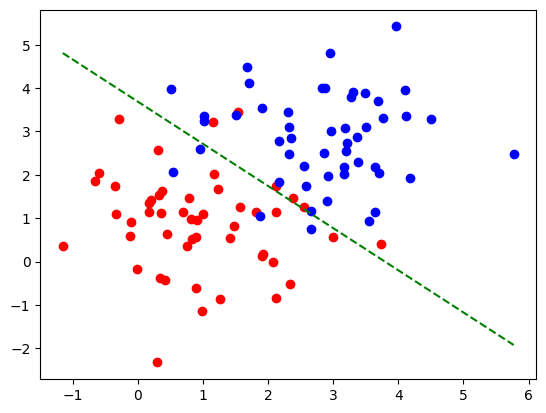

In [9]:
w0 = log_reg.intercept_
w1 = log_reg.coef_[0, 0]
w2 = log_reg.coef_[0, 1]

# w0 + w1*x1 + w2*x2 = 0           a log-reg hipersík egyenlete, cél: y = mx + b egyenlet
# w0 + w1*x + w2*y = 0             (x1 = x, x2 = y)
# y = (-w1/w2)*x + (-w0/w2)        => m= -(w1/w2), b = -w0/w2
m = -w1/w2
b = -w0/w2

x_min = X[:,0].min() # egyik pont
x_max = X[:,0].max() # másik pont
y_at_min_x = m * x_min + b
y_at_max_x = m * x_max + b

plt.scatter(X[0:50,0], X[0:50,1], color="red")
plt.scatter(X[50:100,0], X[50:100,1], color="blue")

plt.plot([x_min, x_max], [y_at_min_x, y_at_max_x], color='green', linestyle='--')

## Linear Discriminant Analysis (LDA)

- más szempontból probálja szeparálni az osztályokat: egy egyenest keres, amelyre levetítve a pontokat:
    - a várható értékeik a kölönböző osztályoknak minnél messzebb esnek
    - minél kisebb legyen az osztályok varianciája

...egyszerre.

Ha $m$ a várható értéke (centroid, átlag) és $\sigma$ a szórása egy osztálynak, akkor a cél:
    
\begin{equation}
max \frac{ ( m_{class1} - m_{class2} )^2 }{ \sigma_{class1}^2 + \sigma_{class2}^2}
\end{equation}


Illusztráció: https://www.georgeho.org/assets/images/lda-pic.png

<div>
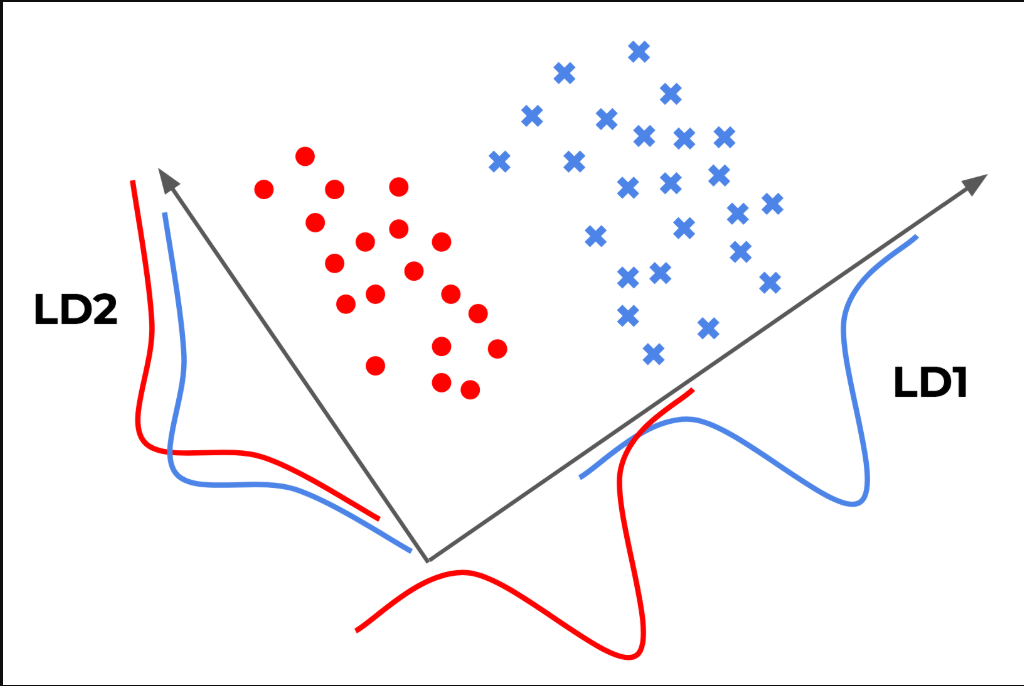
</div>

Feltételezi, hogy:
- függetlenek a bemenetek (ahogy lin. regressziónál)
- az osztályok pontjai normál eloszlásúak
- többé-kevésbé ugyanannyi pont van (balanced)
- ...

In [10]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X, y)

w = lda.coef_ # array (1, p)
b = lda.intercept_ # array (1,)
print("w:", w, "b:", b)
print("BCE:", log_loss(y, lda.predict_proba(X)[:,1]))

w: [[1.96707148 1.84436528]] b: [-7.15086541]
BCE: 0.20122178773234795


## Logit vs. LDA

LogReg BCE: 0.2062069501888163
LDA    BCE: 0.20122178773234795


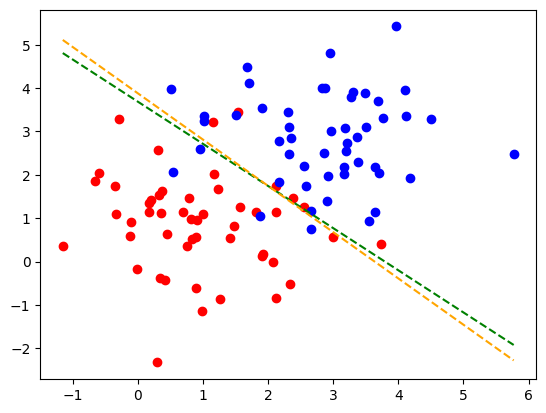

In [11]:
plt.scatter(X[0:50,0], X[0:50,1], color="red")
plt.scatter(X[50:100,0], X[50:100,1], color="blue")

# logit
w0 = log_reg.intercept_
w1 = log_reg.coef_[0, 0]
w2 = log_reg.coef_[0, 1]
plt.plot([x_min, x_max], [-(w1/w2) * x_min - (w0/w2), -(w1/w2) * x_max - (w0/w2)], color='green', linestyle='--')

#lda
w0 = lda.intercept_
w1 = lda.coef_[0, 0]
w2 = lda.coef_[0, 1]
plt.plot([x_min, x_max], [-(w1/w2) * x_min - (w0/w2), -(w1/w2) * x_max - (w0/w2)], color='orange', linestyle='--')

print("LogReg BCE:", log_loss(y, log_reg.predict_proba(X)[:,1]))
print("LDA    BCE:", log_loss(y, lda.predict_proba(X)[:,1]))

---

## Metrikák

- True Positive (TP): pozitív (1) predikció, a tényleges (actual) eredmény is pozitív volt
- False Positive (FP): téves pozitív predikció, a tényleges adat negatív volt
- True Negative (TN): helyesen negatív predikció, negatív adatra
- False Negative (FN): tévesen negatív predikciót számolt a modell, pedig pozitív volt a minta

### Pontosság (accuracy)
Összes helyes predikció / összes adat: $accuracy = \frac{TP+TN}{P+N}$

Jó általános jellemző, de kiegyensúlyozatlan adatoknál nem feltétlenül jó!
Példa: a modellünk mondjon mindig negatívat egy ritka betegég tesztelésekor (pl. COVID) =>
nagy pontosságú lesz a teszt (sok true positive, kevés false negative).

### Érzékenyég (sensitivity, recall, True Positive Rate (TPR))
A ténylegesen pozitívak közül hányat prediktáltunk helyesen pozitívnak: $recall = \frac{TP}{P}$

Példa: halálos vírus, de van rá gyógyszer, ami az egészségesekre sem jelent veszélyt => fontos, hogy ha pozitív az alany, pozitív legyen a teszt, kevésbé kritikus, ha van néhány false positive eredmény.

### Precizitás (precision)
A pozitív predikciók száma, mennyi volt valóban pozitív (megbízhatóság): $precision = \frac{TP}{TP+FP}$

Példa: spam detekció, nem precíz módszer kidobott fontos leveleket => fontos, hogy csak a pozítívak legyenek pozitívnak detektálva, de nem baj ha van pár false negative (néhány spam marad, de fontos levél ne kerüljön a spam folder-be).

### F1 score
Precizitás és érzékenység harmonikus közepe: $F1score = 2\frac{Precision\cdot Recall}{Precision+Recall}$

### False Positive Rate (FPR)
A ténylegesen negatívak közül hányat prediktáltunk tévesen pozitívnak:
$FPR = \frac{FP}{N}$ Téves riasztások valószínűsége, minél __kisebb__, annál __jobb__. 




              precision    recall  f1-score   support

           0       0.85      0.83      0.84       100
           1       0.83      0.85      0.84       100

    accuracy                           0.84       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.84      0.84      0.84       200



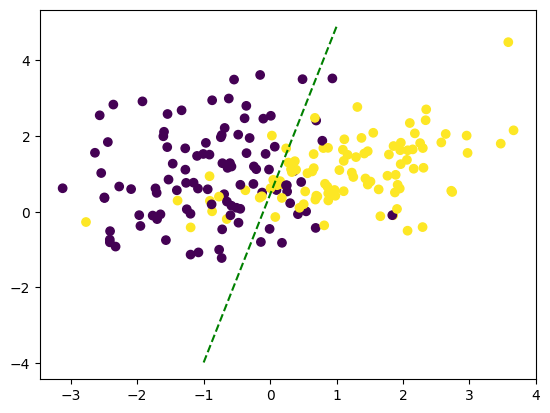

In [12]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
#, random_state=42

model = LogisticRegression()
model.fit(X, y)

plt.scatter(X[:,0], X[:,1], c=y)
x_min = X[:,0].min()
x_max = X[:,0].max()
w0 = model.intercept_
w1 = model.coef_[0, 0]
w2 = model.coef_[0, 1]
plt.plot([-1,1], [-1*(-(w1/w2))-(w0/w2), 1*(-(w1/w2))-(w0/w2)], color='green', linestyle='--')

y_pred = model.predict(X)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)

{
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
}

from sklearn.metrics import classification_report

print(classification_report(y, y_pred)) # precision, recall, f1-score, support

## Confusion mátrix

array([[83, 17],
       [15, 85]])

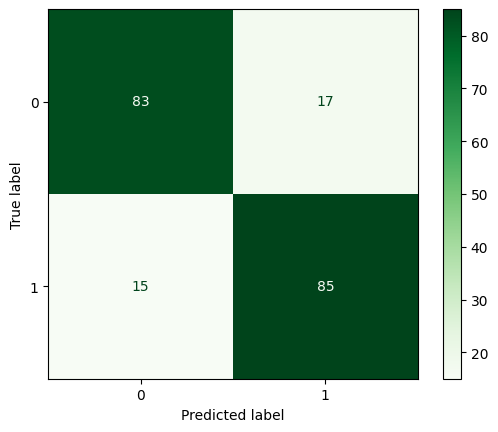

In [19]:
# CONFUSION MATRIX
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

CM = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=CM)
# disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=["Class 1", "Class 2"])
disp.plot(cmap=plt.cm.Greens)
CM

## ROC (Receiver Operating Characteristic) görbe
- ROC bináris osztályozó modell teljesítményét szemlélteti változó küszöbértékek mellett
- Area Under the Curve (AUC): a görbe alatti terület nagysága, minél nagyobb, annál jobb
- bal felső pont a tökéletes osztályozó
- az átló a random prediktort jelent (mindig 1-et vagy 0-át mond, 50%-ban, 90%-ban 1, stb., ...)


AUC: 0.9178


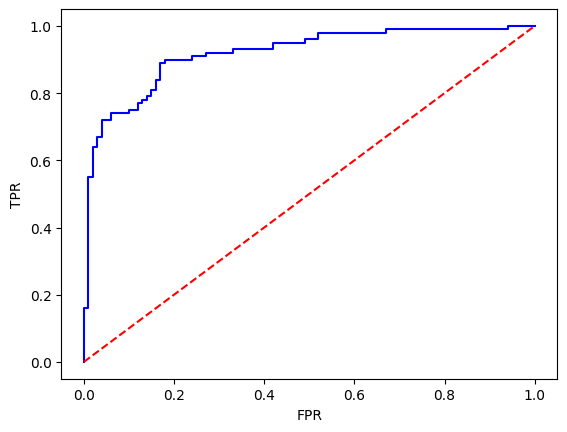

In [14]:
from sklearn.metrics import auc, roc_curve

y_prob = model.predict_proba(X)[:,1] # predict_proba: Logit Sigmoid, LDA esetén Softmax-ot használ (input: távolság)
fpr, tpr, _ = roc_curve(y, y_prob)
# fpr, tpr, _ = roc_curve(y, y_pred) # nem jo
plt.plot(fpr, tpr, color='blue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel("FPR")
plt.ylabel("TPR")

print("AUC:", auc(fpr, tpr))

AUC: 0.9178
TPR at 0.5: 0.85, FPR at 0.5: 0.17


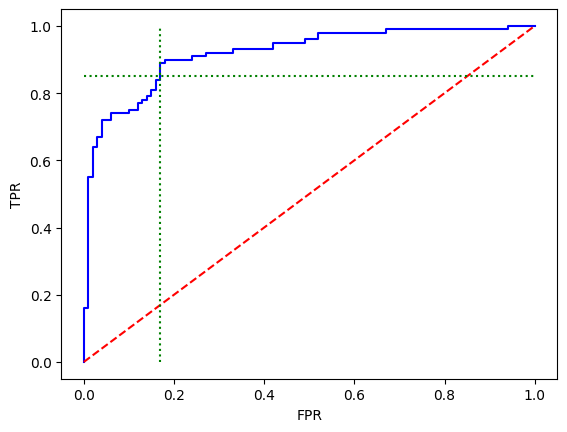

In [15]:
from sklearn.metrics import auc, roc_curve

y_prob = model.predict_proba(X)[:,1]
fpr, tpr, _ = roc_curve(y, y_prob)
plt.plot(fpr, tpr, color='blue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel("FPR")
plt.ylabel("TPR")

roc_auc = auc(fpr, tpr) # Area Under the Curve (AUC)
print("AUC:", roc_auc) # metrika

# 0.5-ös threshold melyik pontot jelöli ki
threshold = 0.5
y_pred_half = (y_prob >= threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y, y_pred_half).flatten()
fpr_05 = fp / (fp + tn)
tpr_05 = tp / (tp + fn) # = recall
print(f"TPR at 0.5: {tpr_05}, FPR at 0.5: {fpr_05}")
plt.plot([0,1], [tpr_05, tpr_05], c="green", linestyle="dotted")
plt.plot([fpr_05,fpr_05], [0, 1], c="green", linestyle="dotted")

## Feladat

- Heart Disease Dataset: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
- adatok betöltése (processed.cleveland.data.csv vagy https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data)
- oszlopnevek: \[ "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"\]
- üres mezők eldobása (a CSV ?-eket tartalmaz, azok üresnek tekintendők!)
- a célváltozó: "target" (target: egészséges: 0; beteg: 1, 2, 3, 4:)
- target legyen kétértékű: 0=egészséges, 1=beteg

- bináris klasszifikáció alkalmazása: Logistic Regression és/vagy LDA
- modell kiértékelése (metrikák, conf. mátr., ROC)


In [16]:
import pandas as pd

columns = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
df = pd.read_csv(url, names=columns)

df.head()
# ...


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
